<a href="https://colab.research.google.com/github/jrangelg/Artificial-intelligence/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Series de Tiempo, LSTM y GRU — Fundamentos Teóricos

## Series de Tiempo

Una serie de tiempo es una secuencia de variables aleatorias indexadas en el tiempo:

\[
\{X_t\}_{t \in T}
\]

donde \( t \) representa el tiempo.

### Propiedades importantes

Estacionariedad débil:
\[
\mathbb{E}[X_t] = \mu, \quad \text{Var}(X_t) = \sigma^2, \quad \text{Cov}(X_t, X_{t+h}) = \gamma(h)
\]

Autocorrelación:
\[
\rho(h) = \frac{\gamma(h)}{\gamma(0)}
\]

---

## Modelos clásicos

Modelo autoregresivo AR(p):
\[
X_t = \sum_{i=1}^{p} \phi_i X_{t-i} + \epsilon_t
\]

Modelo de media móvil MA(q):
\[
X_t = \epsilon_t + \sum_{i=1}^{q} \theta_i \epsilon_{t-i}
\]

Modelo ARMA(p,q):
\[
X_t = \sum_{i=1}^{p} \phi_i X_{t-i} + \epsilon_t + \sum_{i=1}^{q} \theta_i \epsilon_{t-i}
\]

---

## Redes Neuronales Recurrentes

Las redes recurrentes modelan dependencias temporales mediante:

\[
h_t = \tanh(W_h h_{t-1} + W_x x_t + b)
\]

Presentan problemas de desvanecimiento y explosión del gradiente.

---

## LSTM

Las LSTM introducen memoria a largo plazo mediante compuertas.

Puerta de olvido:
\[
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
\]

Puerta de entrada:
\[
i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)
\]

Estado candidato:
\[
\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)
\]

Actualización del estado de celda:
\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]

Puerta de salida:
\[
o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)
\]

Estado oculto:
\[
h_t = o_t \odot \tanh(C_t)
\]

---

## GRU

GRU es una simplificación de LSTM.

Puerta de actualización:
\[
z_t = \sigma(W_z [h_{t-1}, x_t])
\]

Puerta de reinicio:
\[
r_t = \sigma(W_r [h_{t-1}, x_t])
\]

Estado candidato:
\[
\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1}, x_t])
\]

Estado oculto:
\[
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
\]

---

## Comparación

LSTM utiliza tres compuertas y un estado de celda explícito.  
GRU utiliza dos compuertas y no separa estado de celda.  
LSTM tiene más parámetros y mayor capacidad para dependencias largas.  
GRU es más simple y rápido de entrenar.

---

## Interpretación matemática

Ambos modelos aproximan distribuciones condicionales:

\[
P(X_t \mid X_{t-1}, X_{t-2}, \dots)
\]

Se entrenan minimizando funciones de pérdida como:

\[
\mathcal{L} = \sum_t (y_t - \hat{y}_t)^2
\]

---

## Aplicaciones

Predicción financiera  
Series económicas  
Clima  
Señales biomédicas  
Procesamiento de lenguaje natural  

---

## Conexión con procesos estocásticos

Pueden interpretarse como modelos no lineales del tipo:

\[
X_t = f(X_{t-1}, X_{t-2}, \dots) + \epsilon_t
\]

donde \( f \) es aprendida a partir de los datos.

In [1]:
# Instalar dependencias
!pip install pyspark yfinance tensorflow scikit-learn matplotlib

In [2]:
# Configurar Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("LSTM_GRU_Financial") \
    .getOrCreate()

print("Spark listo")

Spark listo


In [3]:
import yfinance as yf
import pandas as pd

# Puedes cambiar por "USDCOP=X" o "DX-Y.NYB"
ticker = "USDCOP=X"

data = yf.download(ticker, start="2015-01-01", end="2024-12-31")

df = data[['Close']].dropna()
df.head()

/tmp/ipykernel_5978/2058891453.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,USDCOP=X
Date,
2015-01-01,2345.199951
2015-01-02,2375.000000
2015-01-05,2430.000000
2015-01-06,2448.000000
2015-01-07,2428.000000


In [4]:
spark_df = spark.createDataFrame(df.reset_index())
spark_df.show(5)

+-------------------+---------------------+
|       ('Date', '')|('Close', 'USDCOP=X')|
+-------------------+---------------------+
|2015-01-01 00:00:00|    2345.199951171875|
|2015-01-02 00:00:00|               2375.0|
|2015-01-05 00:00:00|               2430.0|
|2015-01-06 00:00:00|               2448.0|
|2015-01-07 00:00:00|               2428.0|
+-------------------+---------------------+
only showing top 5 rows


In [5]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

values = df.values

scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(values)

# Crear secuencias
def create_dataset(data, time_step=20):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 20
X, y = create_dataset(scaled, time_step)

# Train/Test
train_size = int(len(X)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# reshape para LSTM/GRU
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(loss='mean_squared_error', optimizer='adam')

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0385 - val_loss: 0.0016
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018 - val_loss: 7.6702e-04
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0014 - val_loss: 2.9427e-04
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 3.8687e-04
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 2.9922e-04
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0013 - val_loss: 3.0394e-04
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0013 - val_loss: 3.7402e-04
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 2.9721e-04
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0013 - val_loss: 3.1761e-04
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0013 - val_loss: 6.7297e-04


In [7]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()
model_gru.add(GRU(50, return_sequences=True, input_shape=(time_step,1)))
model_gru.add(GRU(50))
model_gru.add(Dense(1))

model_gru.compile(loss='mean_squared_error', optimizer='adam')

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0207 - val_loss: 6.7220e-04
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0016 - val_loss: 7.8909e-04
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0014 - val_loss: 2.1206e-04
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0012 - val_loss: 1.3093e-04
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0012 - val_loss: 1.5402e-04
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0012 - val_loss: 1.7538e-04
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0012 - val_loss: 1.5952e-04
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0012 - val_loss: 1.5735e-04
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0012 - val_loss: 3.2473e-04
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0012 - val_loss: 5.1411e-04


In [8]:
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)

# Inversa escala
pred_lstm = scaler.inverse_transform(pred_lstm)
pred_gru = scaler.inverse_transform(pred_gru)

y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

rmse_lstm, mae_lstm = metrics(y_test_real, pred_lstm)
rmse_gru, mae_gru = metrics(y_test_real, pred_gru)

print("LSTM -> RMSE:", rmse_lstm, "MAE:", mae_lstm)
print("GRU  -> RMSE:", rmse_gru, "MAE:", mae_gru)

LSTM -> RMSE: 131.83210489758085 MAE: 111.38726264629585
GRU  -> RMSE: 115.22613807611107 MAE: 101.04628680019304


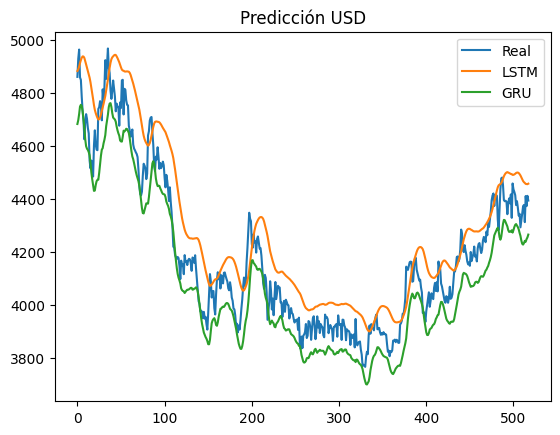

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test_real, label="Real")
plt.plot(pred_lstm, label="LSTM")
plt.plot(pred_gru, label="GRU")
plt.legend()
plt.title("Predicción USD")
plt.show()

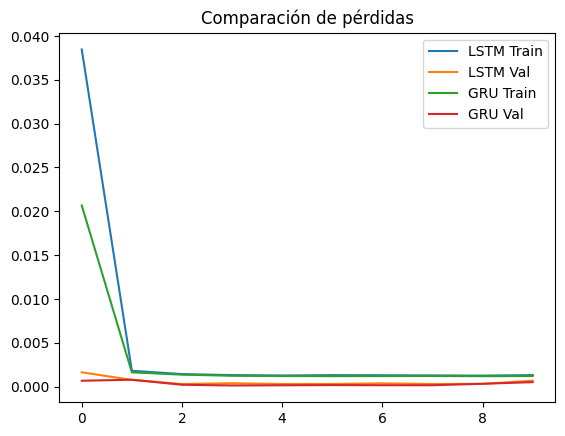

In [11]:
plt.figure()
plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val')

plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Val')

plt.legend()
plt.title("Comparación de pérdidas")
plt.show()

In [12]:
last_data = scaled[-time_step:]
last_data = last_data.reshape(1, time_step, 1)

future_lstm = model_lstm.predict(last_data)
future_gru = model_gru.predict(last_data)

future_lstm = scaler.inverse_transform(future_lstm)
future_gru = scaler.inverse_transform(future_gru)

print("Próximo valor LSTM:", future_lstm[0][0])
print("Próximo valor GRU:", future_gru[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Próximo valor LSTM: 4460.996
Próximo valor GRU: 4269.183
